# Combined ImmVar Dataset QC

This notebook validates the merged CD4 and CD14 datasets and examines the major expression patterns across cell types.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA

## Load and Inspect Expression Matrices


In [2]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"

expression = pd.read_csv(
    DATA_DIR / "immvar_expression_log2.csv",
    index_col=0,
)

metadata = pd.read_csv(
    DATA_DIR / "immvar_metadata.csv",
)

print("Expression:", expression.shape)
print("Metadata:", metadata.shape)

Expression: (21462, 984)
Metadata: (984, 14)


## Inspect the Log2-Transformed Expression Matrix

Probes containing non-positive measurements prior to log2 transform were removed by `03_merge_datasets.py`. This section verifies the distribution of the resulting analysis matrix.


In [3]:
values = expression.to_numpy()

print("Missing values:", expression.isna().sum().sum())
print("Minimum expression:", values.min())
print("Maximum expression:", values.max())

display(
    pd.Series(values.ravel()).describe(
        percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]
    )
)


Missing values: 0
Minimum expression: -2.162944843726976
Maximum expression: 14.63800846131718


count    2.111861e+07
mean     7.125379e+00
std      1.815047e+00
min     -2.162945e+00
0.1%     2.791022e+00
1%       3.460454e+00
50%      7.045962e+00
99%      1.195912e+01
99.9%    1.347397e+01
max      1.463801e+01
dtype: float64

In [4]:
metadata.sample(3)

,geo_accession,sample_title,individual_id,sample_code,cell_type,replicate,age,sex,cell_type_description,batch,inclusion_markers,exclusion_markers,phenotype_markers,separation_method
17,GSM1350873,IGTB1037.4BR1 [CD4],IGTB1037,4,CD4,BR1,20,Male,T4 Naive cells from human peripheral blood mon...,4,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
56,GSM1350912,IGTB1154.4 [CD4],IGTB1154,4,CD4,primary,50,Female,T4 Naive cells from human peripheral blood mon...,3,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
382,GSM1351238,IGTB67.4 [CD4],IGTB67,4,CD4,primary,32,Female,T4 Naive cells from human peripheral blood mon...,3,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter


## Validate the Merge

In [5]:
print(
    "Unique expression sample IDs:",
    expression.columns.is_unique,
)

print(
    "Unique metadata sample IDs:",
    metadata["geo_accession"].is_unique,
)

print(
    "Samples aligned:",
    expression.columns.equals(
        pd.Index(metadata["geo_accession"])
    ),
)

display(metadata["cell_type"].value_counts())

Unique expression sample IDs: True
Unique metadata sample IDs: True
Samples aligned: True


cell_type
CD4     499
CD14    485
Name: count, dtype: int64

## Individual Coverage Across Cell Types

In [6]:
individual_coverage = pd.crosstab(
    metadata["individual_id"],
    metadata["cell_type"],
)

display(individual_coverage.sample(5))

has_cd4 = individual_coverage.get("CD4", 0) > 0
has_cd14 = individual_coverage.get("CD14", 0) > 0

print("Total individuals:", len(individual_coverage))
print("Represented in both:", (has_cd4 & has_cd14).sum())
print("CD4 only:", (has_cd4 & ~has_cd14).sum())
print("CD14 only:", (~has_cd4 & has_cd14).sum())

cell_type,CD14,CD4
individual_id,,
IGTB523,1,1
IGTB111,0,1
IGTB1663,0,1
IGTB1385,1,1
IGTB670,1,1


Total individuals: 515
Represented in both: 388
CD4 only: 66
CD14 only: 61


## PCA by Cell Type

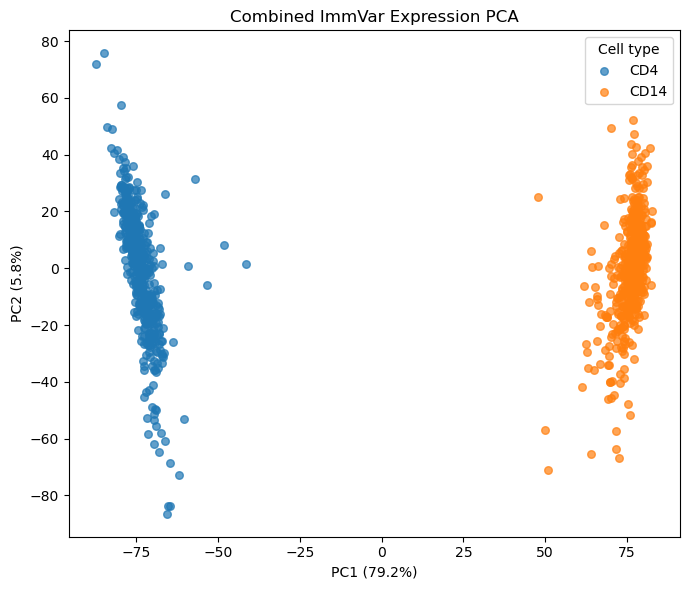

In [7]:
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(expression.T)

pca_results = pd.DataFrame(
    pca_coordinates,
    columns=["PC1", "PC2"],
)

pca_results["cell_type"] = metadata["cell_type"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 6))

for cell_type in ["CD4", "CD14"]:
    mask = pca_results["cell_type"] == cell_type

    ax.scatter(
        pca_results.loc[mask, "PC1"],
        pca_results.loc[mask, "PC2"],
        label=cell_type,
        alpha=0.7,
        s=30,
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)
ax.set_title("Combined ImmVar Expression PCA")
ax.legend(title="Cell type")

plt.tight_layout()
plt.show()

### Observation

- PC1 explains 80.3% of the expression variation and clearly separates CD4 T cells from CD14 monocytes. 
- PC2 explains 5.3% and does not separate the cell types.
- Cell identity is the dominant source of transcriptome wide variation in the combined ImmVar dataset.

## PCA by Batch and Sex

In [8]:
display(
    pd.crosstab(
        metadata["cell_type"],
        metadata["batch"],
    )
)

batch,1,2,3,4,5,6
cell_type,,,,,,
CD14,83,31,98,122,91,60
CD4,71,32,81,138,116,61


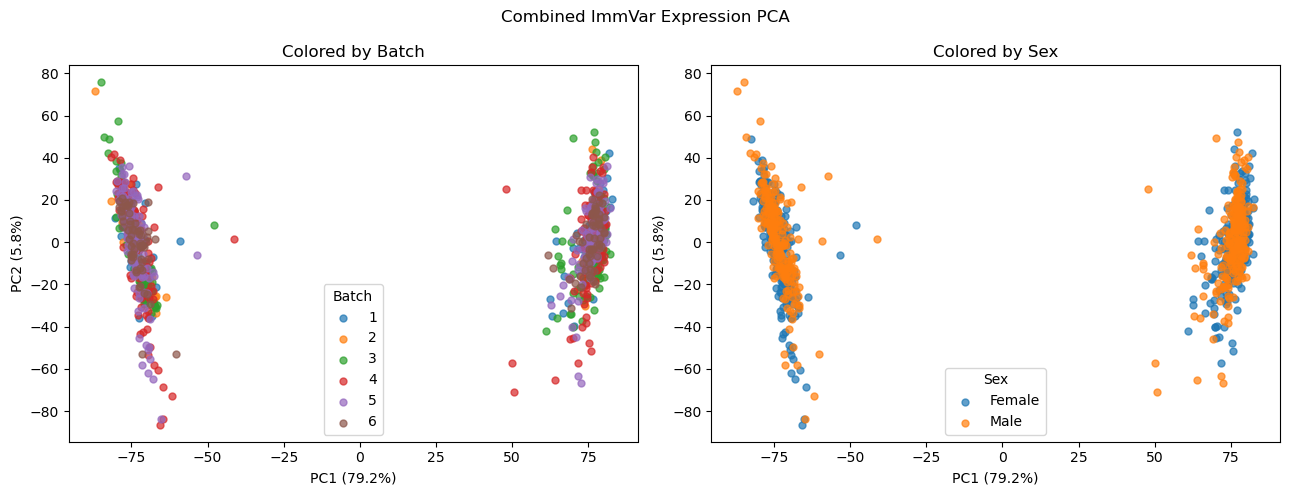

In [9]:
pca_results["batch"] = metadata["batch"].to_numpy()
pca_results["sex"] = metadata["sex"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA colored by batch
for batch in sorted(pca_results["batch"].unique()):
    mask = pca_results["batch"] == batch

    axes[0].scatter(
        pca_results.loc[mask, "PC1"],
        pca_results.loc[mask, "PC2"],
        label=batch,
        alpha=0.7,
        s=25,
    )

axes[0].set_title("Colored by Batch")
axes[0].set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
axes[0].set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)
axes[0].legend(title="Batch")

# PCA colored by sex
for sex in sorted(pca_results["sex"].unique()):
    mask = pca_results["sex"] == sex

    axes[1].scatter(
        pca_results.loc[mask, "PC1"],
        pca_results.loc[mask, "PC2"],
        label=sex,
        alpha=0.7,
        s=25,
    )

axes[1].set_title("Colored by Sex")
axes[1].set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
axes[1].set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)
axes[1].legend(title="Sex")

fig.suptitle("Combined ImmVar Expression PCA")
plt.tight_layout()
plt.show()

## Summary

The merged ImmVar dataset passed the combined QC checks:

- After filtering and log2 transformation, the expression matrix contains 21,462 probes and 984 samples.
- Expression and metadata sample identifiers are unique and correctly aligned.
- Both CD4 and CD14 samples are represented across all six batches.
- Many individuals contributed samples from both cell types
- PC1 explains 80.3% of total expression variation and clearly separates CD4 T cells from CD14 monocytes.
- PC2 explains 5.3% of the variation.
- Batch and sex do not produce obvious separation in the first two principal components.

These results indicate that cell type is the dominant transcriptome-wide source of variation and support modeling cell type, individual, batch, sex, and age in the combined variance-partition analysis.



## Paired-Donor Subset

PCA was repeated after restricting the data to individuals represented in both cell types. 

In [10]:
cell_types_per_individual = (
    metadata
    .groupby("individual_id")["cell_type"]
    .nunique()
)

paired_individuals = cell_types_per_individual[
    cell_types_per_individual == 2
].index

paired_metadata_by_sample = (
    metadata.loc[
        metadata["individual_id"].isin(paired_individuals)
    ]
    .set_index("geo_accession")
)

paired_sample_ids = expression.columns[
    expression.columns.isin(paired_metadata_by_sample.index)
]

paired_expression = expression.loc[:, paired_sample_ids]

paired_metadata_by_sample = paired_metadata_by_sample.loc[
    paired_expression.columns
]

assert paired_expression.columns.equals(
    paired_metadata_by_sample.index
)

print("Paired individuals:", len(paired_individuals))
print("Paired expression:", paired_expression.shape)
print("Paired metadata:", paired_metadata_by_sample.shape)

display(
    paired_metadata_by_sample["cell_type"].value_counts()
)


Paired individuals: 388
Paired expression: (21462, 847)
Paired metadata: (847, 13)


cell_type
CD4     427
CD14    420
Name: count, dtype: int64

In [11]:
paired_pca = PCA(n_components=2)

paired_coordinates = paired_pca.fit_transform(
    paired_expression.T
)

paired_pca_results = pd.DataFrame(
    paired_coordinates,
    index=paired_expression.columns,
    columns=["PC1", "PC2"],
)

paired_pca_results = paired_pca_results.join(
    paired_metadata_by_sample[
        ["cell_type", "batch", "sex"]
    ]
)

assert not paired_pca_results[
    ["cell_type", "batch", "sex"]
].isna().any().any()

print(
    "PC1 variance explained:",
    f"{paired_pca.explained_variance_ratio_[0] * 100:.1f}%"
)
print(
    "PC2 variance explained:",
    f"{paired_pca.explained_variance_ratio_[1] * 100:.1f}%"
)


PC1 variance explained: 79.4%
PC2 variance explained: 5.8%


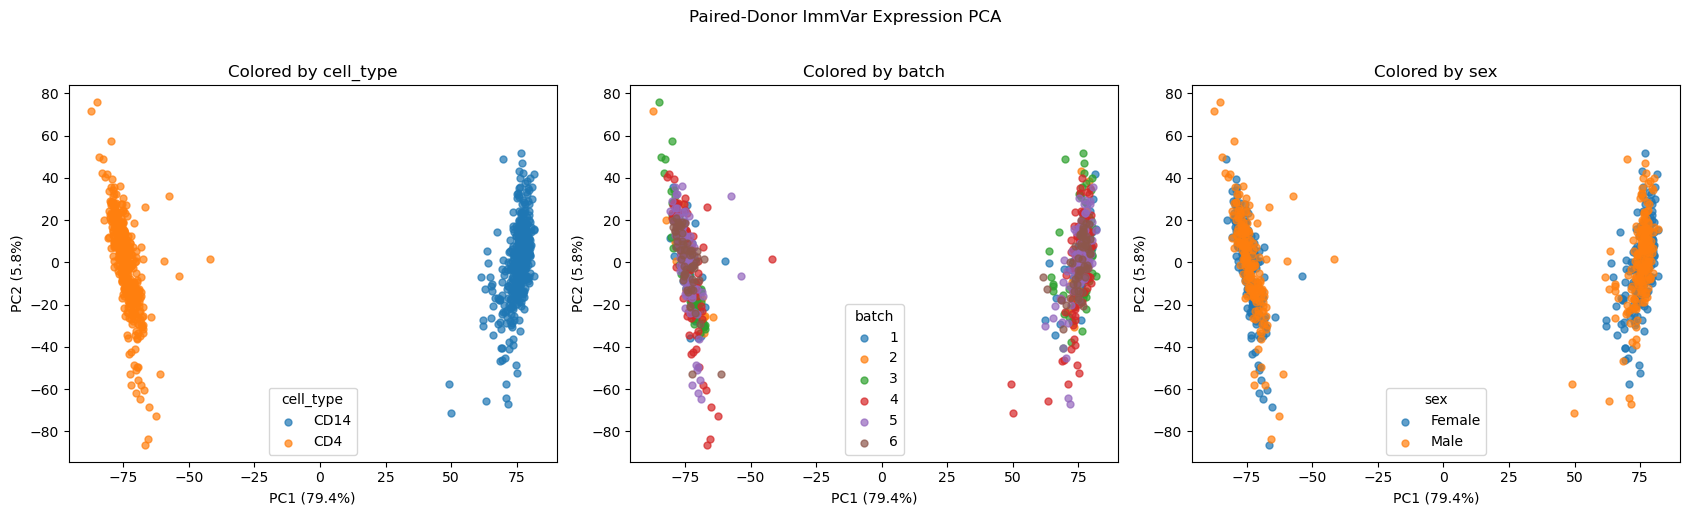

In [12]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
)

for ax, variable in zip(
    axes,
    ["cell_type", "batch", "sex"],
):
    for group, group_data in paired_pca_results.groupby(
        variable
    ):
        ax.scatter(
            group_data["PC1"],
            group_data["PC2"],
            label=str(group),
            alpha=0.7,
            s=25,
        )

    ax.set_title(f"Colored by {variable}")
    ax.set_xlabel(
        f"PC1 ({paired_pca.explained_variance_ratio_[0] * 100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({paired_pca.explained_variance_ratio_[1] * 100:.1f}%)"
    )
    ax.legend(title=variable)

plt.suptitle(
    "Paired-Donor ImmVar Expression PCA",
    y=1.02,
)
plt.tight_layout()
plt.show()


## Conclusions

Restricting the analysis to 388 individuals with data for both cell types produced a PCA pattern nearly identical to the all-sample analysis. PC1 explains 79.4% of the variance and clearly separates CD4 T cells from CD14 monocytes, demonstrating that the cell-type effect was not driven by unpaired samples. Some batch associated patterns may be present along PC2, but batches remained substantially intermixed and did not form distinct clusters.
